In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [2]:
!kaggle datasets download -d meowmeowmeowmeowmeow/gtsrb-german-traffic-sign

Dataset URL: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
License(s): CC0-1.0
100% 612M/612M [00:06<00:00, 98.2MB/s]



In [3]:
import zipfile
zip_ref = zipfile.ZipFile('/content/gtsrb-german-traffic-sign.zip')
zip_ref.extractall('/content')
zip_ref.close()


## Library import

In [13]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models, Sequential
from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import Activation, Rescaling, Flatten, Conv2D, Dense, MaxPooling2D, BatchNormalization, GlobalAvgPool2D, GlobalMaxPooling2D, LeakyReLU, Dropout
from tensorflow.keras.applications import MobileNetV2

## dataset split

In [7]:
from sklearn.utils import validation
dataset_path = '/content/Train'

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split = .2,
    subset = 'training',
    seed = 42,
    image_size = (64, 64),
    batch_size = 32
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split = .2,
    subset = 'validation',
    seed = 42,
    image_size = (64, 64),
    batch_size = 32
)

Found 39209 files belonging to 43 classes.
Using 31368 files for training.
Found 39209 files belonging to 43 classes.
Using 7841 files for validation.


## Simple CNN from scratch

In [14]:
model = Sequential([

    Rescaling(1./ 255 , input_shape = (64, 64, 3)),

    Conv2D(32, (3,3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(43, activation='softmax')  # 43 classes

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,285,099 (4.90 MB)

 Trainable params: 1,284,651 (4.90 MB)

 Non-trainable params: 448 (1.75 KB)

In [22]:
# Compile Model

model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [23]:
history = model.fit(train_ds, validation_data  = validation_ds, epochs=30)

Epoch 1/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.3350 - loss: 2.1989 - val_accuracy: 0.7549 - val_loss: 0.8540
Epoch 2/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.5141 - loss: 1.4157 - val_accuracy: 0.8542 - val_loss: 0.5310
Epoch 3/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.5525 - loss: 1.2777 - val_accuracy: 0.8966 - val_loss: 0.4620
Epoch 4/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.5829 - loss: 1.1769 - val_accuracy: 0.9189 - val_loss: 0.4028
Epoch 5/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.6112 - loss: 1.1110 - val_accuracy: 0.9269 - val_loss: 0.3134
Epoch 6/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.6543 - loss: 0.9982 - val_accuracy: 0.9519 - val_loss: 0.2223
Epoch 7/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.6693 - loss: 0.9422 - val_accuracy: 0.9594 - val_loss: 0.2107
Epoch 8/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.6789 - loss: 0.9071 - 

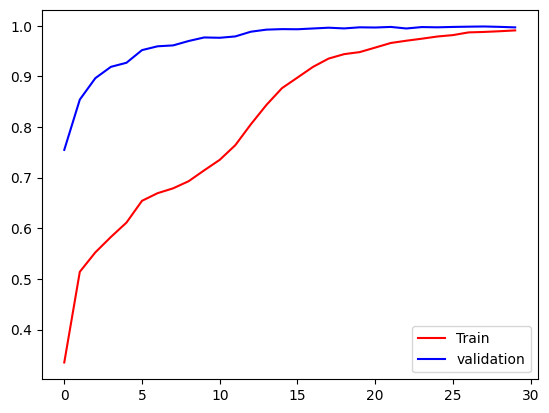

In [25]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color = 'red', label = "Train")
plt.plot(history.history['val_accuracy'], color = 'blue', label = "validation")
plt.legend()
plt.show()

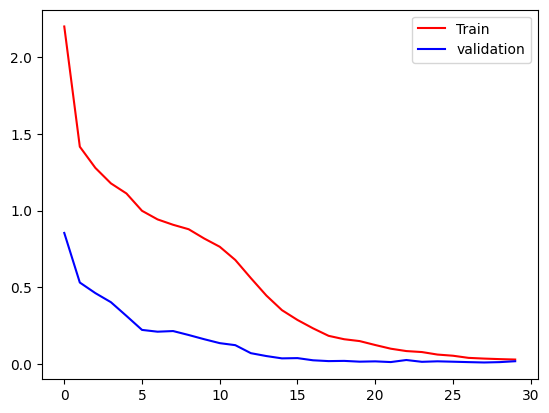

In [26]:


plt.plot(history.history['loss'], color = 'red', label = "Train")
plt.plot(history.history['val_loss'], color = 'blue', label = "validation")
plt.legend()
plt.show()